In [37]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

In [38]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 1. Data Preparation

In [39]:
import pandas as pd
import torch

df = pd.read_csv(r'../dataset/assignment-data.csv')
df.head(5)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92


In [40]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


In [41]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [42]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

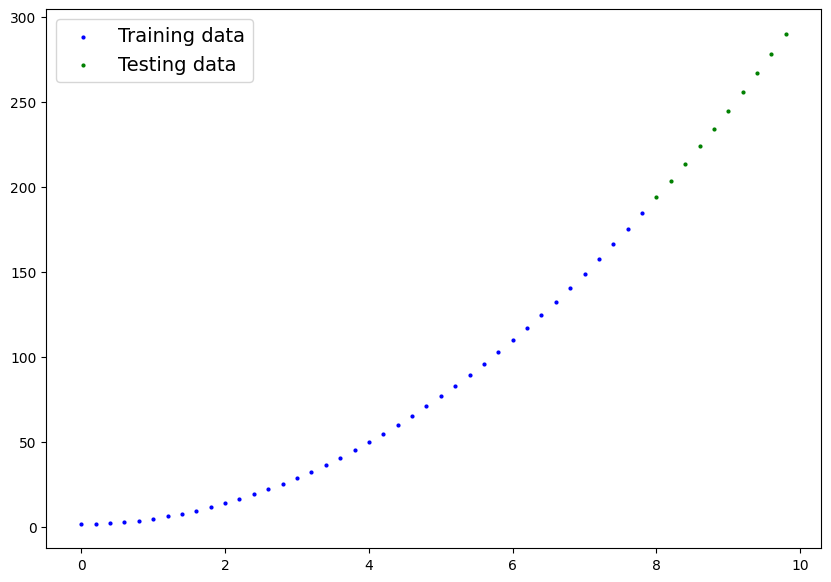

In [43]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

## Algorithm Selection

In [44]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [45]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionNN()

# Check the nn.Parameter(s) within the nn.Module subclass we created
# list(model_0.parameters())

In [46]:
print(model_0.linear.weight.dtype)
print(model_0.linear.bias.dtype)

torch.float32
torch.float32


In [47]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579]])

- As the name suggests, `torch.inference_mode()` is used when using a model for `inference` (making predictions).
    - it turns off gradient tracking (which is not necessary for inference/prediction)
    

In [48]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579],
        [7.7109],
        [7.8638],
        [8.0167],
        [8.1696],
        [8.3225]])


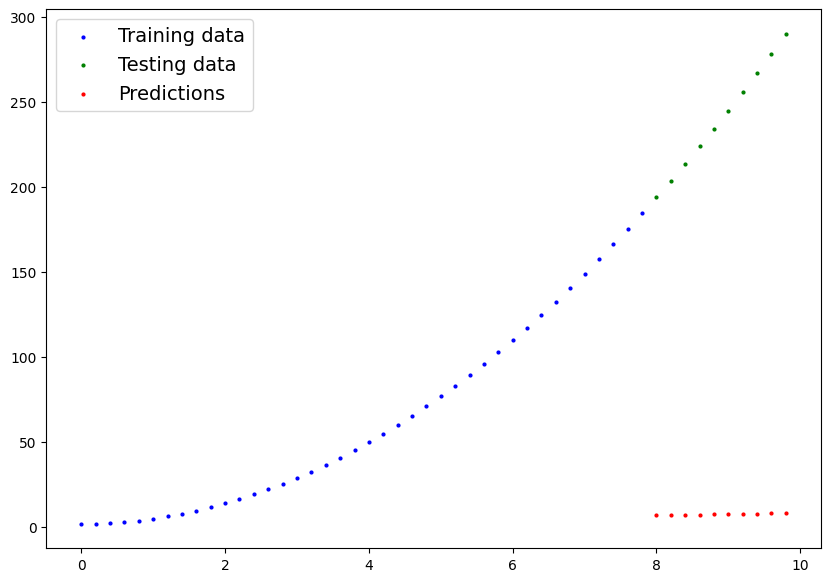

In [49]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [50]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

MAE is the average absolute difference between true values (y_i) and predictions (ŷ_i).
$$\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert$$

- Lower MAE → better fit.
- More robust to outliers than MSE (no squaring).

Here, our optimizer is SGD which is short for Stochastic Gradient Descent (SGD). 

The reason for the name: 
- the gradient is computed from a stochastic (random) sample of the training data rather than the entire dataset

### Model Training

In [51]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 2000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 59.80829620361328 | MAE Test Loss: 232.6284942626953 
Epoch: 10 | MAE Train Loss: 58.187294006347656 | MAE Test Loss: 229.0574951171875 
Epoch: 20 | MAE Train Loss: 56.56629180908203 | MAE Test Loss: 225.4864959716797 
Epoch: 30 | MAE Train Loss: 54.945289611816406 | MAE Test Loss: 221.91549682617188 
Epoch: 40 | MAE Train Loss: 53.32429122924805 | MAE Test Loss: 218.34451293945312 
Epoch: 50 | MAE Train Loss: 51.70328903198242 | MAE Test Loss: 214.7734832763672 
Epoch: 60 | MAE Train Loss: 50.12068557739258 | MAE Test Loss: 211.242919921875 
Epoch: 70 | MAE Train Loss: 48.60227584838867 | MAE Test Loss: 207.7753448486328 
Epoch: 80 | MAE Train Loss: 47.13697052001953 | MAE Test Loss: 204.36285400390625 
Epoch: 90 | MAE Train Loss: 45.713233947753906 | MAE Test Loss: 200.9970703125 
Epoch: 100 | MAE Train Loss: 44.328060150146484 | MAE Test Loss: 197.67660522460938 
Epoch: 110 | MAE Train Loss: 42.97723388671875 | MAE Test Loss: 194.39744567871094 
Epoch: 120

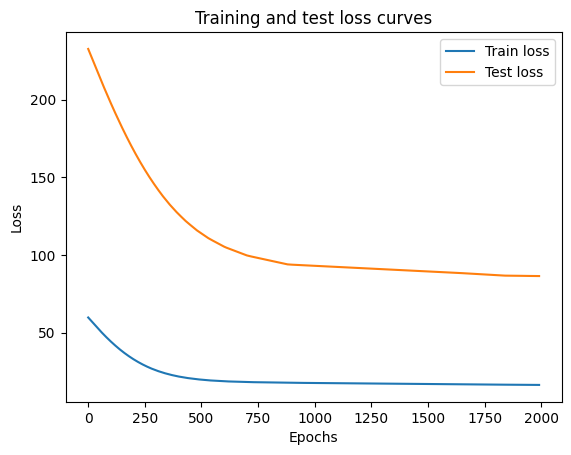

In [52]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [53]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'linear.weight': tensor([[17.6071]]), 'linear.bias': tensor([-2.5220])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


*This is the whole idea of machine learning and deep learning, there are some ideal values that describe our data and rather than figuring them out by hand, we can train a model to figure them out programmatically.*

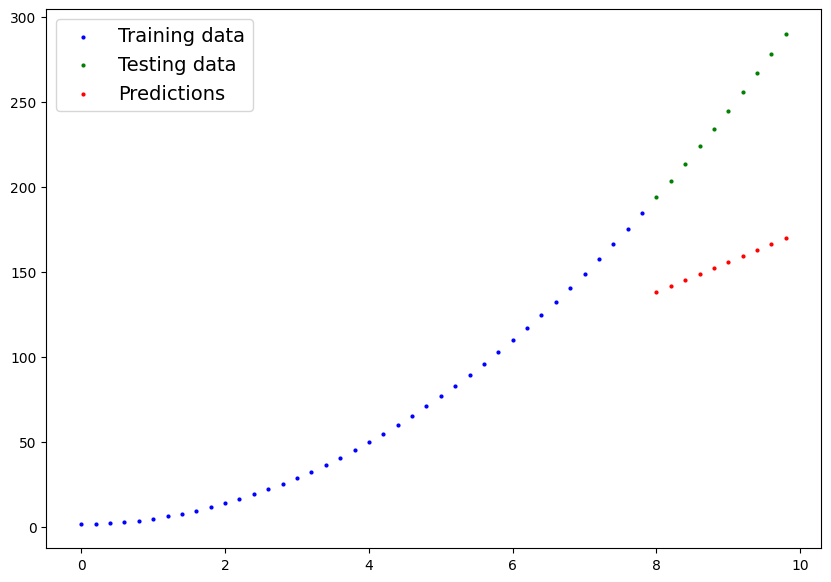

In [54]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)